In [4]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, BaseLineDataLoaderManager, DeepDataLoaderManager, GraphDataLoaderManager
# get data
# get data
disease_name    = 'covid_daily'
nuts_level      = 'nuts3'
min_date        = '2020-03-02'
max_date        = '2023-01-01'
split_trainval  = '2022-06-01'
split_valtest   = '2022-09-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 7
sequence_length = 7
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    temporal_frequency   = "d",
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  ,
    weekly_time_index   = False,
    daily_time_index    = True,
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

sl = BaseLineDataLoaderManager(data_orchestrator)
dl = DeepDataLoaderManager(data_orchestrator).construct_dataloaders()

gl1 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()
gl2 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()
gl3 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_1').construct_dataloaders()

In [5]:
import torch 
import torch.nn as nn

class MinimalGRURegressor(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, num_layers= int):
        super().__init__()
        self.gru = nn.GRU(
            input_size  = input_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True
        )
        self.gru_out_norm = nn.LayerNorm(hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, X: torch.Tensor):
        # X: [nodes, seq_len, features]
        n = X.shape[0]
        h0 = torch.zeros(self.gru.num_layers, n, self.gru.hidden_size, device=X.device)
        _, new_hidden = self.gru(X, h0)

        
        ht_gru = self.gru_out_norm(new_hidden[-1])
        return self.fc(ht_gru)   # [n, output_dim]


In [6]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATv2Conv
import torch.nn.functional as F

class GRU_GATv2_Regressor(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, gat_hidden_dim: int,
                 output_dim: int, num_layers=2, gat_heads=2):
        super().__init__()

        # GRU module
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.gru_out_norm = nn.LayerNorm(hidden_dim)

        # GATv2 module
        self.gat1 = GATv2Conv(hidden_dim, gat_hidden_dim, heads=gat_heads, concat=True)
        self.gat2 = GATv2Conv(gat_hidden_dim * gat_heads, gat_hidden_dim, heads=gat_heads, concat=True)

        # Final output layer
        self.fc = nn.Linear(gat_hidden_dim * gat_heads + hidden_dim, output_dim)  # concat ht_gru as skip connection

    def forward(self, X: torch.Tensor, edge_index: torch.Tensor):
        """
        X: [num_nodes, seq_len, features] 
        edge_index: [2, num_edges], standard PyG edge_index
        """
        n = X.shape[0]
        device = X.device

        # GRU forward
        h0 = torch.zeros(self.gru.num_layers, n, self.gru.hidden_size, device=device)
        _, new_hidden = self.gru(X, h0)
        ht_gru = self.gru_out_norm(new_hidden[-1])  # [n, hidden_dim]

        # GATv2 forward
        h = F.relu(self.gat1(ht_gru, edge_index))
        h = F.relu(self.gat2(h, edge_index))

        # Concatenate GRU embedding (skip connection)
        h_cat = torch.cat([h, ht_gru], dim=-1)

        # Final output
        out = self.fc(h_cat)  # [n, output_dim]
        return out


Epoch 1 training-Loss: 0.1731 validation-Loss 0.4627✓
Epoch 2 training-Loss: 0.1550 validation-Loss 0.4451✓
Epoch 3 training-Loss: 0.1485 validation-Loss 0.4082✓
Epoch 4 training-Loss: 0.1465 validation-Loss 0.3858✓
Epoch 5 training-Loss: 0.1470 validation-Loss 0.3656✓
Epoch 6 training-Loss: 0.1468 validation-Loss 0.3461✓
Epoch 7 training-Loss: 0.1478 validation-Loss 0.3266✓
Epoch 8 training-Loss: 0.1483 validation-Loss 0.3121✓
Epoch 9 training-Loss: 0.1487 validation-Loss 0.3012✓
Epoch 10 training-Loss: 0.1490 validation-Loss 0.2908✓
Epoch 11 training-Loss: 0.1489 validation-Loss 0.2824✓
Epoch 12 training-Loss: 0.1491 validation-Loss 0.2748✓
Epoch 13 training-Loss: 0.1492 validation-Loss 0.2675✓
Epoch 14 training-Loss: 0.1491 validation-Loss 0.2643✓
Epoch 15 training-Loss: 0.1488 validation-Loss 0.2537✓
Epoch 16 training-Loss: 0.1488 validation-Loss 0.2484✓
Epoch 17 training-Loss: 0.1486 validation-Loss 0.2427✓
Epoch 18 training-Loss: 0.1475 validation-Loss 0.2402✓
Epoch 19 training-L

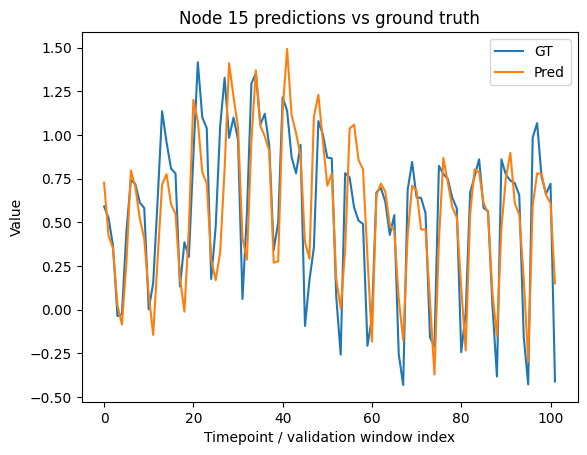

In [100]:
import torch
from torch import optim
from tqdm import tqdm

trainingloader  = gl1.dataloader_collection.train
valloader       = gl1.dataloader_collection.val
testloader      = gl1.dataloader_collection.test

from src.utils.textformatting import checkmark
# data
n            = 400
f            = 3
d            = 7

# model
hidden_dim_gru   = 32
hidden_dim_gat   = 64
num_layers   = 2
patience = 50
epochs = 500
delta = 0.0005

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model1 = GRU_GATv2_Regressor(input_dim=f, hidden_dim=hidden_dim_gru, gat_hidden_dim=hidden_dim_gat, output_dim=1, num_layers=2).to(device)
optimizer = optim.Adam(model1.parameters(), lr=1e-4)
criterion = nn.MSELoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=15,
    min_lr=1e-7
)

patience_counter = 0
best_val_loss = 1e6

for epoch in range(epochs):

    # TRAINING PHASE
    model1.train()
    training_loss = 0.0
    for deepdata in trainingloader:
        X_t = deepdata.x.to(device)  # [nodes, features, seq_len]
        y_t = deepdata.y.to(device)  # [nodes, 1]
        e_i = deepdata.edge_index.to(device)

        X_t = X_t.permute(0, 2, 1)  # [nodes, seq_len, features]

        optimizer.zero_grad()
        y_pred = model1(X_t, e_i)          # [nodes, output_dim]
        loss = criterion(y_pred, y_t)
        loss.backward()
        optimizer.step()

        training_loss += loss.item()# * X_t.size(0)

    # VALIDATION PHASE
    model1.eval()
    validation_loss = 0
    with torch.no_grad():
        for deepdata in valloader:
            X_t = deepdata.x.to(device)          # [nodes, features, seq_len]
            y_t = deepdata.y.to(device)
            e_i = deepdata.edge_index.to(device)            

            X_t = X_t.permute(0, 2, 1)          # [nodes, seq_len, features]
            y_pred = model1(X_t, e_i)                  # [nodes, output_dim]
            loss = criterion(y_pred, y_t)
            validation_loss += loss.item()

    training_loss  = training_loss / len(trainingloader)
    validation_loss= validation_loss / len(valloader)

    val_improved = validation_loss <(best_val_loss - delta)
    update = f"Epoch {epoch+1} training-Loss: {training_loss:.4f} validation-Loss {validation_loss:.4f}"
    # if so => save best model
    if val_improved:
        best_val_loss   = validation_loss
        patience_counter= 0
        best_model_state= model1.state_dict().copy()  
        update += checkmark
    else:
        patience_counter += 1       

    if patience_counter > patience:
        print('patience clompleted. Aborting training')
        break

       
    scheduler.step(validation_loss)
    print(update)

model1.load_state_dict(best_model_state)

import torch
import matplotlib.pyplot as plt
import seaborn as sns

node_idx = 15  # the node you’re tracking

model1.eval()
node_preds = []

with torch.no_grad():
    for deepdata in testloader:
        X_t = deepdata.x.to(device)          # [nodes, features, seq_len]
        e_i = deepdata.edge_index.to(device)        
        X_t = X_t.permute(0, 2, 1)          # [nodes, seq_len, features]
        y_pred = model1(X_t,e_i)                  # [nodes, output_dim]
        node_preds.append(y_pred[node_idx].cpu().item())

# Ground truth for this node
node_gt = [deepdata.y[node_idx].item() for deepdata in testloader]

# Plot
sns.lineplot(node_gt, label='GT')
sns.lineplot(node_preds, label='Pred')
plt.xlabel('Timepoint / validation window index')
plt.ylabel('Value')
plt.title(f'Node {node_idx} predictions vs ground truth')
plt.legend()
# plt.xlim(700,800)
plt.show()


Epoch 1 training-Loss: 0.1845 validation-Loss 0.4999✓
Epoch 2 training-Loss: 0.1692 validation-Loss 0.4579✓
Epoch 3 training-Loss: 0.1620 validation-Loss 0.4028✓
Epoch 4 training-Loss: 0.1573 validation-Loss 0.3520✓
Epoch 5 training-Loss: 0.1547 validation-Loss 0.3234✓
Epoch 6 training-Loss: 0.1537 validation-Loss 0.2975✓
Epoch 7 training-Loss: 0.1529 validation-Loss 0.2808✓
Epoch 8 training-Loss: 0.1523 validation-Loss 0.2703✓
Epoch 9 training-Loss: 0.1519 validation-Loss 0.2615✓
Epoch 10 training-Loss: 0.1516 validation-Loss 0.2592✓
Epoch 11 training-Loss: 0.1511 validation-Loss 0.2494✓
Epoch 12 training-Loss: 0.1509 validation-Loss 0.2463✓
Epoch 13 training-Loss: 0.1507 validation-Loss 0.2412✓
Epoch 14 training-Loss: 0.1500 validation-Loss 0.2394✓
Epoch 15 training-Loss: 0.1495 validation-Loss 0.2373✓
Epoch 16 training-Loss: 0.1491 validation-Loss 0.2344✓
Epoch 17 training-Loss: 0.1486 validation-Loss 0.2330✓
Epoch 18 training-Loss: 0.1482 validation-Loss 0.2325✓
Epoch 19 training-L

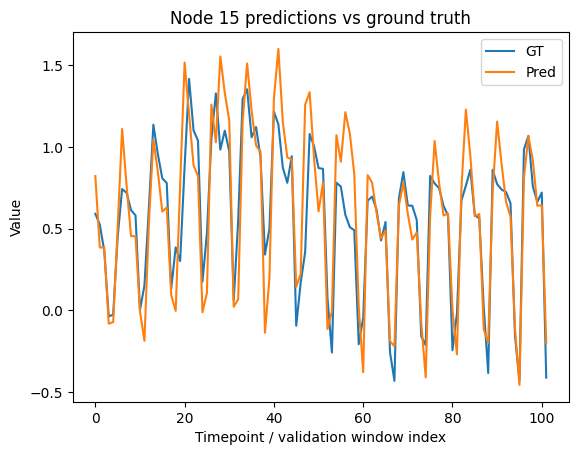

In [8]:
import torch
from torch import optim
from tqdm import tqdm

trainingloader  = gl2.dataloader_collection.train
valloader       = gl2.dataloader_collection.val
testloader      = gl2.dataloader_collection.test

from src.utils.textformatting import checkmark
# data
n            = 400
f            = 3
d            = 7

# model
hidden_dim_gru   = 32
hidden_dim_gat   = 64
num_layers   = 2
patience = 50

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model2 = GRU_GATv2_Regressor(input_dim=f, hidden_dim=hidden_dim_gru, gat_hidden_dim=hidden_dim_gat, output_dim=1, num_layers=2).to(device)
optimizer = optim.Adam(model2.parameters(), lr=1e-4)
criterion = nn.MSELoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=15,
    min_lr=1e-7
)

patience_counter = 0
best_val_loss = 1e6

for epoch in range(epochs):

    # TRAINING PHASE
    model2.train()
    training_loss = 0.0
    for deepdata in trainingloader:
        X_t = deepdata.x.to(device)  # [nodes, features, seq_len]
        y_t = deepdata.y.to(device)  # [nodes, 1]
        e_i = deepdata.edge_index.to(device)

        X_t = X_t.permute(0, 2, 1)  # [nodes, seq_len, features]

        optimizer.zero_grad()
        y_pred = model2(X_t, e_i)          # [nodes, output_dim]
        loss = criterion(y_pred, y_t)
        loss.backward()
        optimizer.step()

        training_loss += loss.item()# * X_t.size(0)

    # VALIDATION PHASE
    model2.eval()
    validation_loss = 0
    with torch.no_grad():
        for deepdata in valloader:
            X_t = deepdata.x.to(device)          # [nodes, features, seq_len]
            y_t = deepdata.y.to(device)
            e_i = deepdata.edge_index.to(device)            

            X_t = X_t.permute(0, 2, 1)          # [nodes, seq_len, features]
            y_pred = model2(X_t, e_i)                  # [nodes, output_dim]
            loss = criterion(y_pred, y_t)
            validation_loss += loss.item()

    training_loss  = training_loss / len(trainingloader)
    validation_loss= validation_loss / len(valloader)

    val_improved = validation_loss <( best_val_loss - delta)
    update = f"Epoch {epoch+1} training-Loss: {training_loss:.4f} validation-Loss {validation_loss:.4f}"
    # if so => save best model
    if val_improved:
        best_val_loss   = validation_loss
        patience_counter= 0
        best_model_state= model2.state_dict().copy()  
        update += checkmark
    else:
        patience_counter += 1       

    if patience_counter > patience:
        break

       
    scheduler.step(validation_loss)
    print(update)

model2.load_state_dict(best_model_state)

import torch
import matplotlib.pyplot as plt
import seaborn as sns

node_idx = 15  # the node you’re tracking

model2.eval()
node_preds = []

with torch.no_grad():
    for deepdata in testloader:
        X_t = deepdata.x.to(device)          # [nodes, features, seq_len]
        e_i = deepdata.edge_index.to(device)        
        X_t = X_t.permute(0, 2, 1)          # [nodes, seq_len, features]
        y_pred = model2(X_t,e_i)                  # [nodes, output_dim]
        node_preds.append(y_pred[node_idx].cpu().item())

# Ground truth for this node
node_gt = [deepdata.y[node_idx].item() for deepdata in testloader]

# Plot
sns.lineplot(node_gt, label='GT')
sns.lineplot(node_preds, label='Pred')
plt.xlabel('Timepoint / validation window index')
plt.ylabel('Value')
plt.title(f'Node {node_idx} predictions vs ground truth')
plt.legend()
# plt.xlim(700,800)
plt.show()


Epoch 1 training-Loss: 0.2554 validation-Loss 0.6490✓
Epoch 2 training-Loss: 0.1886 validation-Loss 0.5553✓
Epoch 3 training-Loss: 0.1729 validation-Loss 0.4702✓
Epoch 4 training-Loss: 0.1624 validation-Loss 0.4020✓
Epoch 5 training-Loss: 0.1567 validation-Loss 0.3439✓
Epoch 6 training-Loss: 0.1529 validation-Loss 0.3094✓
Epoch 7 training-Loss: 0.1511 validation-Loss 0.3004✓
Epoch 8 training-Loss: 0.1505 validation-Loss 0.2772✓
Epoch 9 training-Loss: 0.1511 validation-Loss 0.2680✓
Epoch 10 training-Loss: 0.1509 validation-Loss 0.2643✓
Epoch 11 training-Loss: 0.1505 validation-Loss 0.2531✓
Epoch 12 training-Loss: 0.1505 validation-Loss 0.2508✓
Epoch 13 training-Loss: 0.1506 validation-Loss 0.2468✓
Epoch 14 training-Loss: 0.1505 validation-Loss 0.2423✓
Epoch 15 training-Loss: 0.1500 validation-Loss 0.2400✓
Epoch 16 training-Loss: 0.1497 validation-Loss 0.2443
Epoch 17 training-Loss: 0.1498 validation-Loss 0.2388✓
Epoch 18 training-Loss: 0.1489 validation-Loss 0.2353✓
Epoch 19 training-Lo

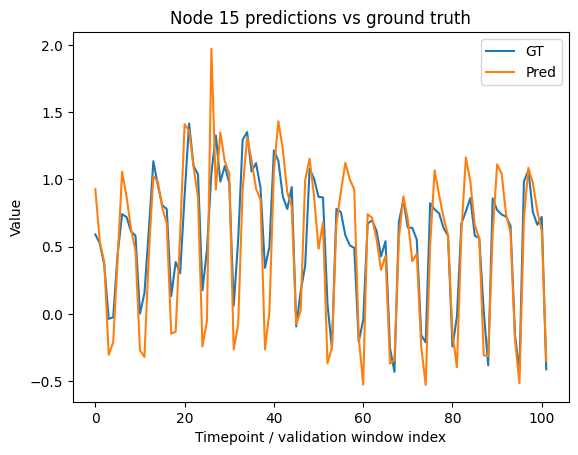

In [9]:
import torch
from torch import optim
from tqdm import tqdm

trainingloader  = gl3.dataloader_collection.train
valloader       = gl3.dataloader_collection.val
testloader      = gl3.dataloader_collection.test

from src.utils.textformatting import checkmark
# data
n            = 400
f            = 3
d            = 7

# model
hidden_dim_gru   = 32
hidden_dim_gat   = 64
num_layers   = 2
patience = 50

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model3 = GRU_GATv2_Regressor(input_dim=f, hidden_dim=hidden_dim_gru, gat_hidden_dim=hidden_dim_gat, output_dim=1, num_layers=2).to(device)
optimizer = optim.Adam(model3.parameters(), lr=1e-4)
criterion = nn.MSELoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=15,
    min_lr=1e-7
)

patience_counter = 0
best_val_loss = 1e6

for epoch in range(epochs):

    # TRAINING PHASE
    model3.train()
    training_loss = 0.0
    for deepdata in trainingloader:
        X_t = deepdata.x.to(device)  # [nodes, features, seq_len]
        y_t = deepdata.y.to(device)  # [nodes, 1]
        e_i = deepdata.edge_index.to(device)

        X_t = X_t.permute(0, 2, 1)  # [nodes, seq_len, features]

        optimizer.zero_grad()
        y_pred = model3(X_t, e_i)          # [nodes, output_dim]
        loss = criterion(y_pred, y_t)
        loss.backward()
        optimizer.step()

        training_loss += loss.item()# * X_t.size(0)

    # VALIDATION PHASE
    model3.eval()
    validation_loss = 0
    with torch.no_grad():
        for deepdata in valloader:
            X_t = deepdata.x.to(device)          # [nodes, features, seq_len]
            y_t = deepdata.y.to(device)
            e_i = deepdata.edge_index.to(device)            

            X_t = X_t.permute(0, 2, 1)          # [nodes, seq_len, features]
            y_pred = model3(X_t, e_i)                  # [nodes, output_dim]
            loss = criterion(y_pred, y_t)
            validation_loss += loss.item()

    training_loss  = training_loss / len(trainingloader)
    validation_loss= validation_loss / len(valloader)

    val_improved = validation_loss <( best_val_loss - delta)
    update = f"Epoch {epoch+1} training-Loss: {training_loss:.4f} validation-Loss {validation_loss:.4f}"
    # if so => save best model
    if val_improved:
        best_val_loss   = validation_loss
        patience_counter= 0
        best_model_state= model3.state_dict().copy()  
        update += checkmark
    else:
        patience_counter += 1       

    if patience_counter > patience:
        break

       
    scheduler.step(validation_loss)
    print(update)

model3.load_state_dict(best_model_state)

import torch
import matplotlib.pyplot as plt
import seaborn as sns

node_idx = 15  # the node you’re tracking

model3.eval()
node_preds = []

with torch.no_grad():
    for deepdata in testloader:
        X_t = deepdata.x.to(device)          # [nodes, features, seq_len]
        e_i = deepdata.edge_index.to(device)        
        X_t = X_t.permute(0, 2, 1)          # [nodes, seq_len, features]
        y_pred = model3(X_t,e_i)                  # [nodes, output_dim]
        node_preds.append(y_pred[node_idx].cpu().item())

# Ground truth for this node
node_gt = [deepdata.y[node_idx].item() for deepdata in testloader]

# Plot
sns.lineplot(node_gt, label='GT')
sns.lineplot(node_preds, label='Pred')
plt.xlabel('Timepoint / validation window index')
plt.ylabel('Value')
plt.title(f'Node {node_idx} predictions vs ground truth')
plt.legend()
# plt.xlim(700,800)
plt.show()


In [94]:
import pandas as pd
import torch

t1 = '2022-09-14'
t2 = '2022-12-25'

def return_model_preds(model):

    model.eval()

    all_data = []

    t1_dt = pd.to_datetime(t1)
    t2_dt = pd.to_datetime(t2)

    # Generate daily dates
    dates = pd.date_range(start=t1_dt, end=t2_dt - pd.Timedelta(days=1), freq='D')
    date_idx = 0  # to iterate over dates

    with torch.no_grad():
        for deepdata in testloader:
            X_t = deepdata.x.to(device)           # [nodes, features, seq_len]
            e_i = deepdata.edge_index.to(device)
            X_t = X_t.permute(0, 2, 1)           # [nodes, seq_len, features]
            y_pred = model(X_t, e_i)            # [nodes, output_dim]

            current_date = dates[date_idx]       # pick the date for this batch
            
            # For each node, append pred and target
            for node_idx in range(y_pred.shape[0]):
                all_data.append({
                    'node': node_idx,
                    'pred': y_pred[node_idx].cpu().item(),
                    'target': deepdata.y[node_idx].item(),
                    'timestamp': current_date
                })

            date_idx +=1
            if date_idx >= len(dates):
                break

    # Create a long DataFrame
    return pd.DataFrame(all_data)
   


# lets see how well this does

In [101]:
# FAKE MODEL CLASS 

from src.models.base.predictions_manager import PredictionManager

class FakeClass:

    def __init__(self, model_name, dataorchestrator: DataOrchestrator):
        self.name = model_name
        self.prediction_mode = 'regression'
        self.clean_model_name = model_name
        self.model_class = 'gatv2_newgen'
        self.model_color = '#1b9e77'

        self.predictions = PredictionManager(dataorchestrator.config, dataorchestrator.column_registration)

model1_fc             = FakeClass('gru_gatv2_regressor_ig', data_orchestrator)
model1_fc.predictions.add_horizon_predictions('test', return_model_preds(model1), 0)

model2_fc             = FakeClass('gru_gatv2_regressor_gn', data_orchestrator)
model2_fc.predictions.add_horizon_predictions('test', return_model_preds(model2), 0)

model3_fc             = FakeClass('gru_gatv2_regressor_commutergraph', data_orchestrator)
model3_fc.predictions.add_horizon_predictions('test', return_model_preds(model3), 0)


In [90]:
from src.dataloading import ShallowDataLoaderManager, GraphDataLoaderManager, BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel

ps = PersistenceModel(sl)
cm = ClimateologyModel(sl)

ps.forecast('test')
raw_f1 = ps.show_forecasts([26], 'test')

cm.forecast('test')
raw_f2 = cm.show_forecasts([26], 'test')

computing metrics:   0%|                                                                                                                                                                | 0/6 [00:00<?, ?it/s]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.07it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

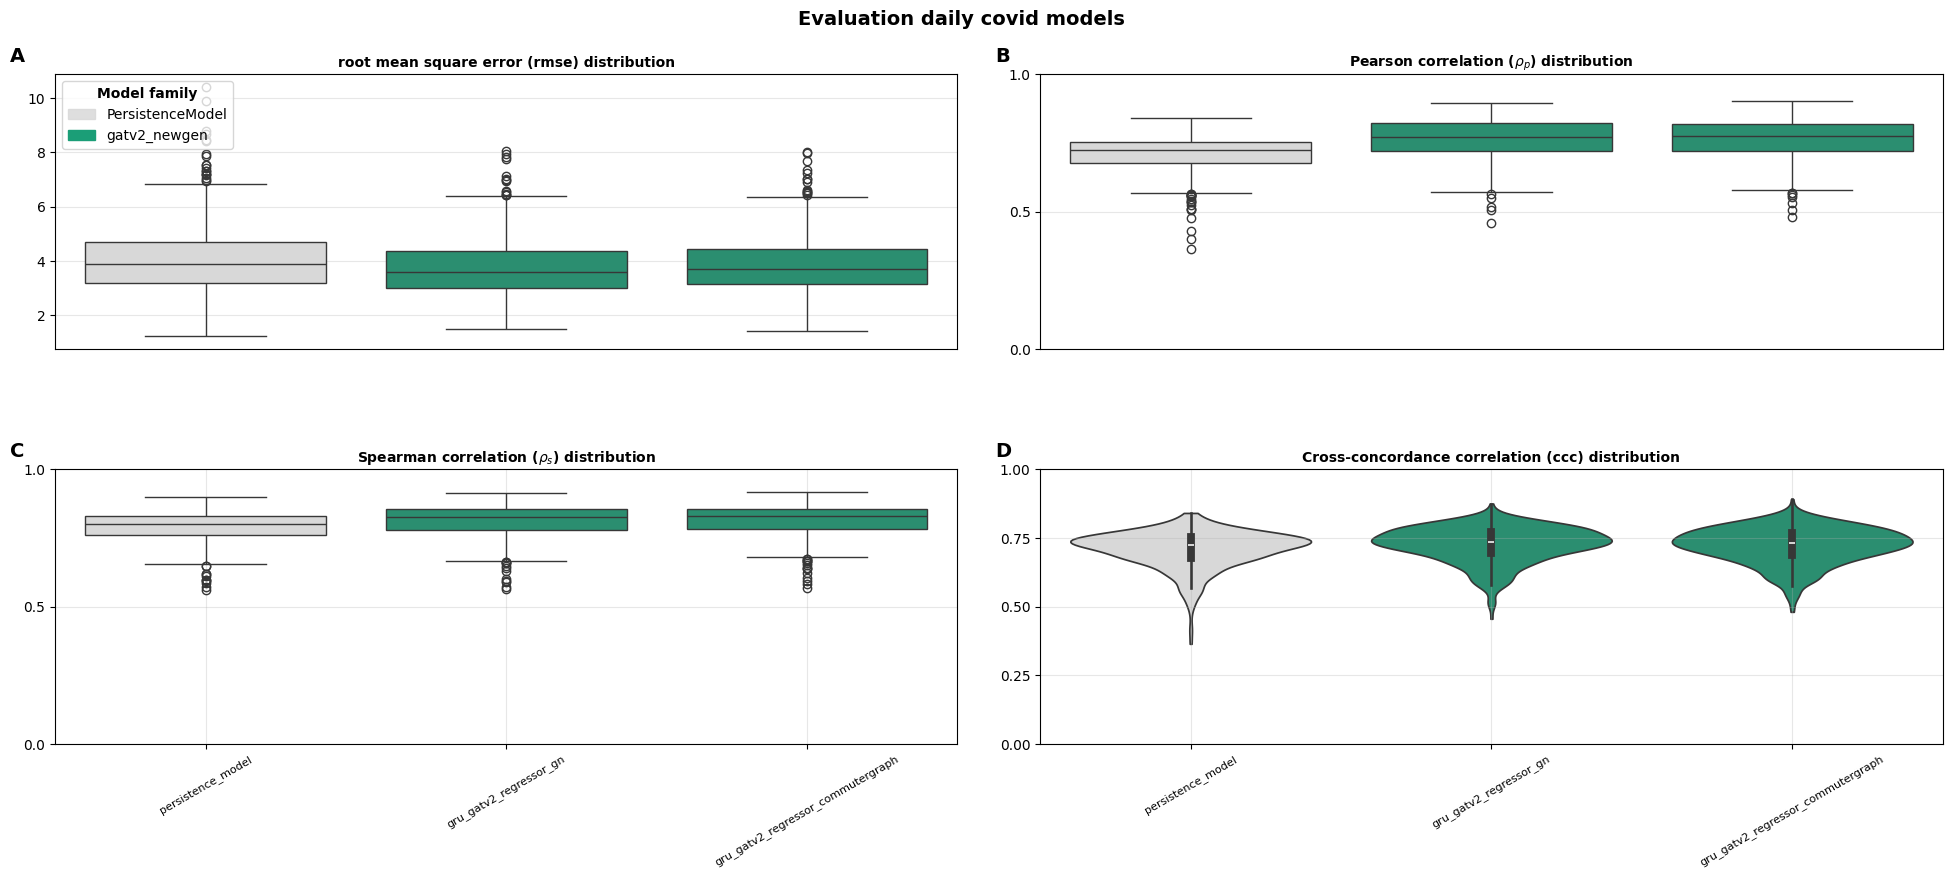

In [ ]:
from src.evaluation import Evaluator

e = Evaluator([ps, model1_fc, model2_fc, model3_fc]).add_evaluation()
raw_figure = e.plotter.plot_metric_compilation(plot_types = ['box','box','box','violin'], metrics = ['rmse','pearson_corr','spearman_corr','ccc'])

f_evaluation = (raw_figure
    .labels.change_suptitle(suptitle='Evaluation daily covid models', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 0)      
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 1)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 2)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([], ax = 0)
    .ticks.change_xticks([], ax = 1)    
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 1)
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 2)
    .ticks.change_yticks(ticks = [0,0.25,0.5,0.75,1], ax = 3)    
    .ticks.rotate_xticks(30)
    .layout.set_ylim([0,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)
    .layout.set_ylim([0,1],ax = 3)        
    .labels.change_legend_title('Model family',fontweight = 'bold',ax=0)
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)      
    .change_figsize(20,8)         
    )
f_evaluation.show()